In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import scipy.stats as stats
from scipy.stats import f_oneway
# from statannotations.Annotator import Annotator
import matplotlib.patheffects as PathEffects
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.dates as mdates

# Read data

## Sensors measurement data

In [2]:
# read sensors data
sensors_data_path = 'data/Smart_Citizen_Data_clean/'

sensors_data = {}

for data_path in os.listdir(sensors_data_path):
    df = pd.read_csv(sensors_data_path+data_path)

    # set datetime as index
    df['TIME'] = pd.to_datetime(df['TIME'])
    # round the datetime to the nearest minute
    df['TIME'] = df['TIME'].dt.floor('min')
    df = df.set_index('TIME')

    sensors_data[data_path[:-4]] = df

## Building data

In [3]:
df_building = pd.read_csv('data/Combined_sensor_ID_EPC_look_up_update.csv')

In [4]:
df_building_ori = pd.read_csv('data/epc_concat_original.csv')

## Outdoor weather data

In [5]:
station_limbo = pd.read_csv('data/LIMBO.csv')

In [6]:
station_limbo['Report Date / Time'] = pd.to_datetime(station_limbo['Report Date / Time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Convert field to datetime type 
station_limbo['Report Date / Time'] = pd.to_datetime(station_limbo['Report Date / Time'])  

In [7]:
station_limbo.index = station_limbo['Report Date / Time']

In [8]:
# time filter
start_time = '2023-07-28'
end_time = '2023-09-26'

station_limbo = station_limbo.loc[start_time:end_time]

In [9]:
station_limbo.columns

Index(['Id', 'Site Id', 'Longitude', 'Latitude', 'Report Date / Time',
       'Air Temperature', 'Wet Bulb', 'Dew Point', 'Concrete Temp.',
       'Grass Temp.', 'Min. Temp. (last 24hr)', 'Max. Temp. (last 24hr)',
       'Soil Temp. (at 10cm)', 'Soil Temp. (at 30cm)', 'Soil Temp. (at 100cm)',
       'Mean Sea-Level Pressure', 'Pressure (At Station)', 'Relative Humidity',
       'Rainfall Rate', 'Rainfall Accumulation', 'Rainfall', 'Wind Speed',
       'Wind Direction', 'Wind Gust', 'Wind Gust Direction', 'Snow Depth',
       'Soil Moisture', 'Present Weather', 'Visibility', 'Total Cloud Cover',
       'Sunshine', 'Ground State', 'Day of Thunder', 'Day of Gales',
       'Day of Hail', 'Day of Snow', 'Weather Diary', 'Travel Disruption',
       'Hazards causing Travel Disruption',
       'Property or Infrastructure Damage',
       'Hazards causing Property or Infrastructure Damage',
       'Personal Health and Safety',
       'Hazards causing Personal Health and Safety', 'Utility Disrupt

# Temporal temperature illustration

In [10]:
sensors_data = {
    sensor: df.groupby(df.index).mean()
    for sensor, df in sensors_data.items()
}

temperature_df = pd.concat(
    {sensor: df['TEMP'] for sensor, df in sensors_data.items()},
    axis=1
)

temperature_df['mean'] = temperature_df.mean(axis=1)
temperature_df['std'] = temperature_df.std(axis=1)

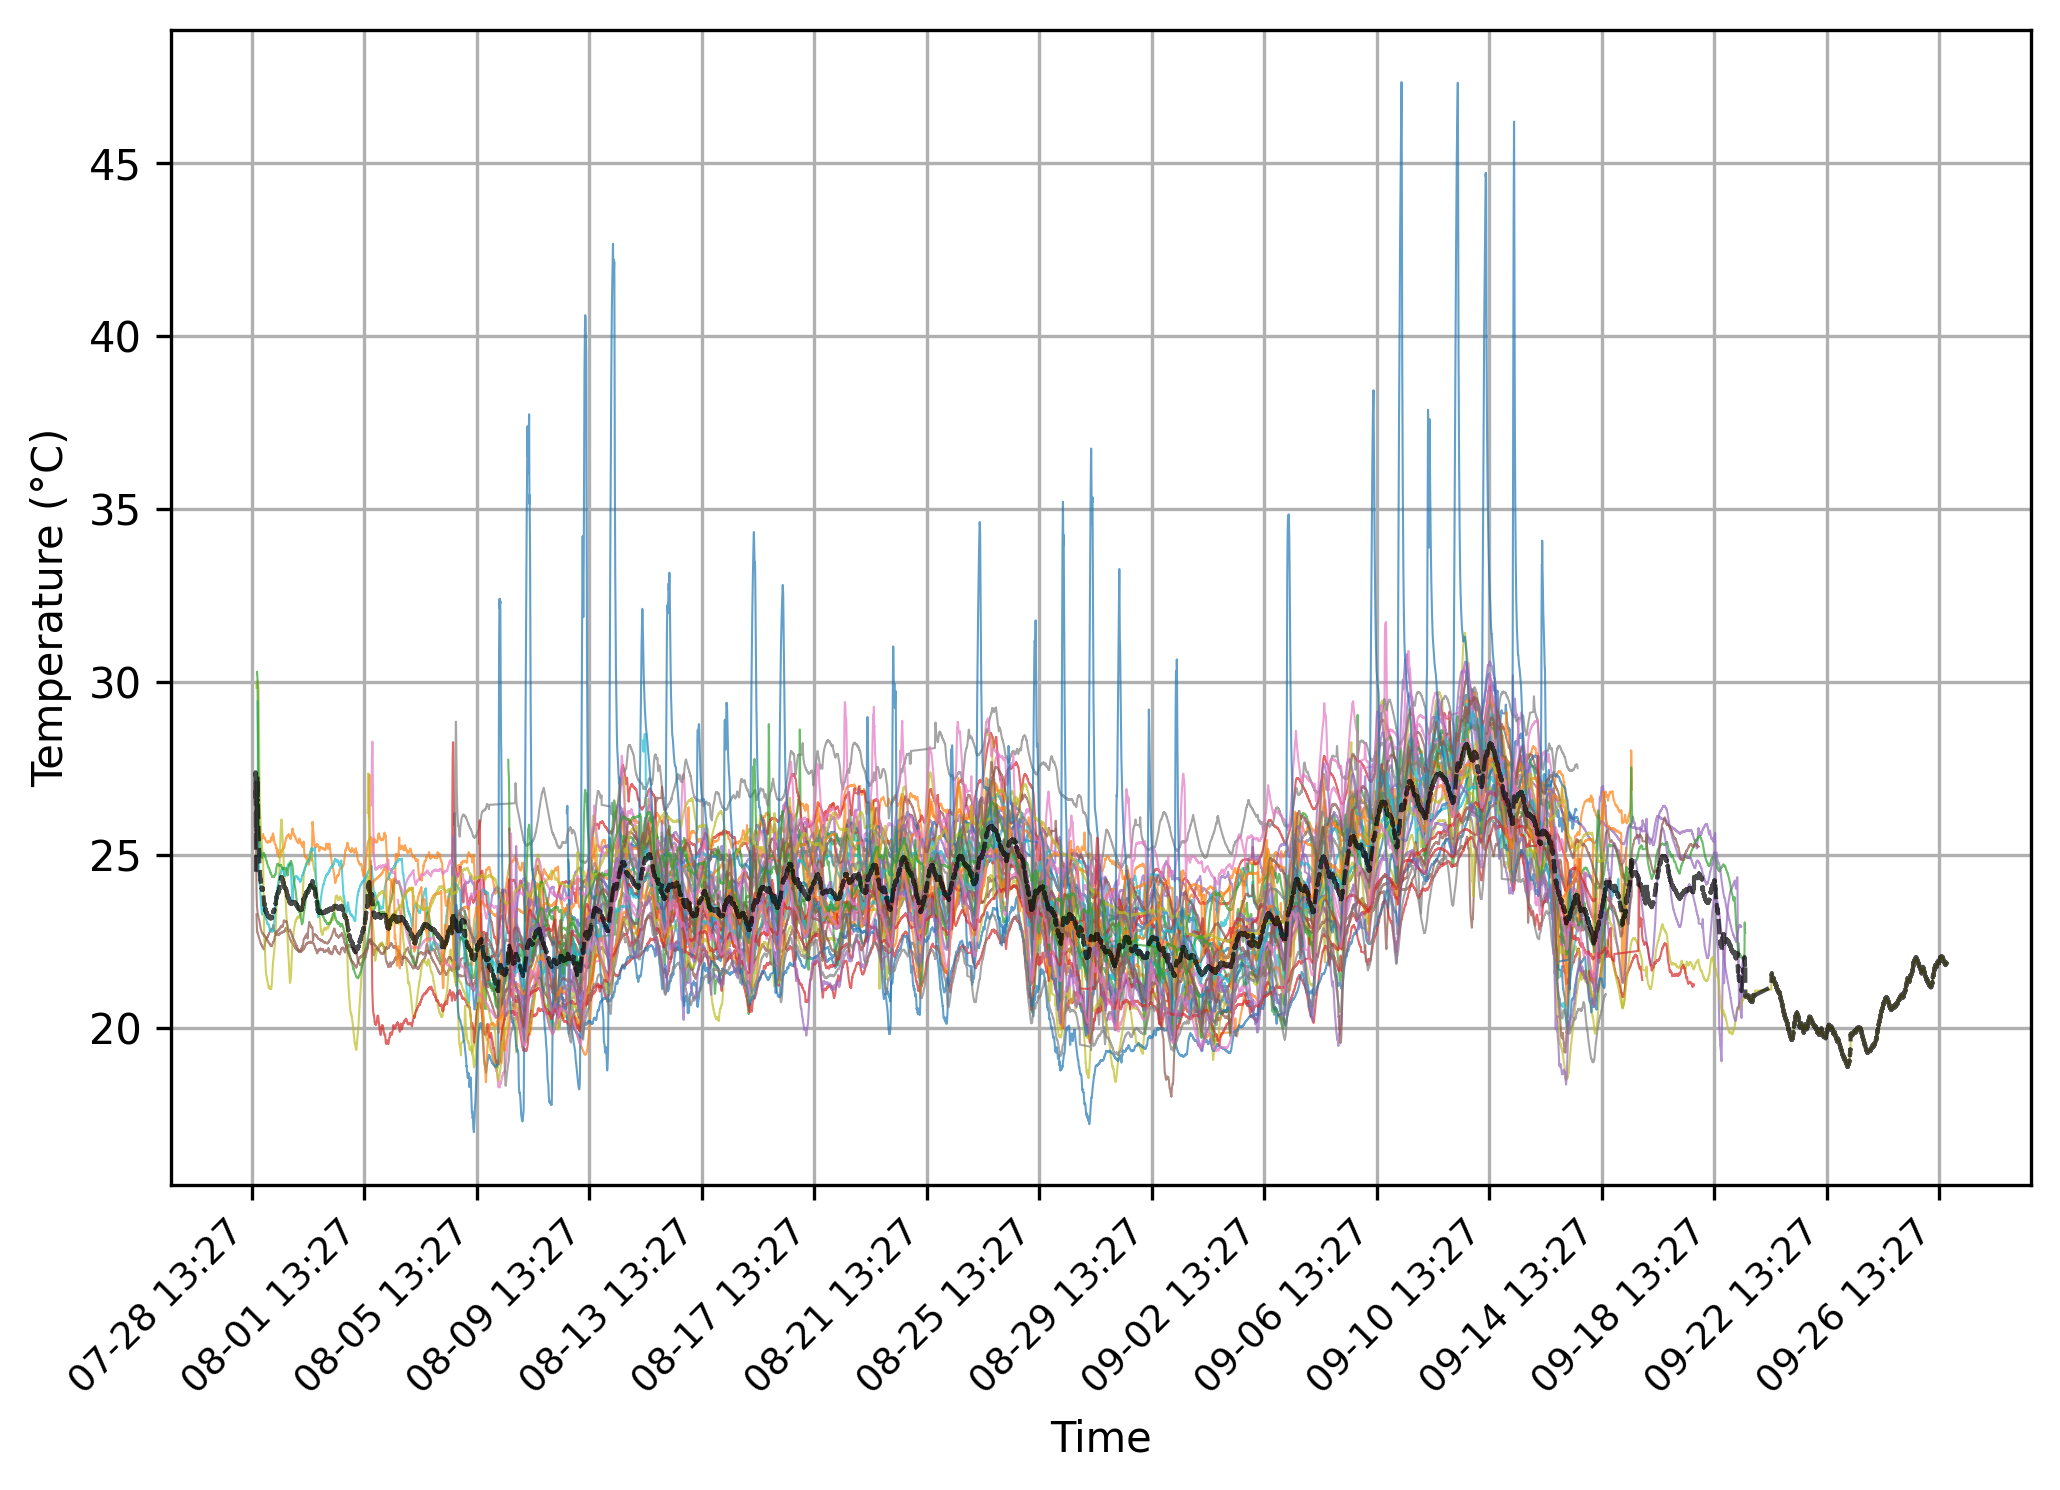

In [11]:
# Plot: each sensor and mean
fig, ax1 = plt.subplots(figsize=(8, 5),dpi=300)
ax1.grid(True)

# one line for each sensor with rolling mean 
for sensor_id, df in sensors_data.items():
    df['temp_smooth'] = df['TEMP'].rolling(window=10, center=True).mean()
    ax1.plot(df.index, df['temp_smooth'], label=f'{sensor_id}', linestyle='-', alpha=0.7, linewidth=0.5)

# mean of all sensors
ax1.plot(temperature_df.index, temperature_df['mean'], c='black', alpha=0.7,linewidth=1, linestyle='--', label='Mean value')

lines, labels = ax1.get_legend_handles_labels()
ax1.xaxis.set_major_locator(mdates.RRuleLocator(mdates.rrulewrapper(mdates.DAILY, interval=4)))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

# ax1.legend(lines, labels,loc='lower right',framealpha=0.6)
ax1.set_xlabel('Time')
ax1.set_ylabel('Temperature (°C)')
plt.xticks(rotation=45,ha='right',fontsize=9)

plt.show()

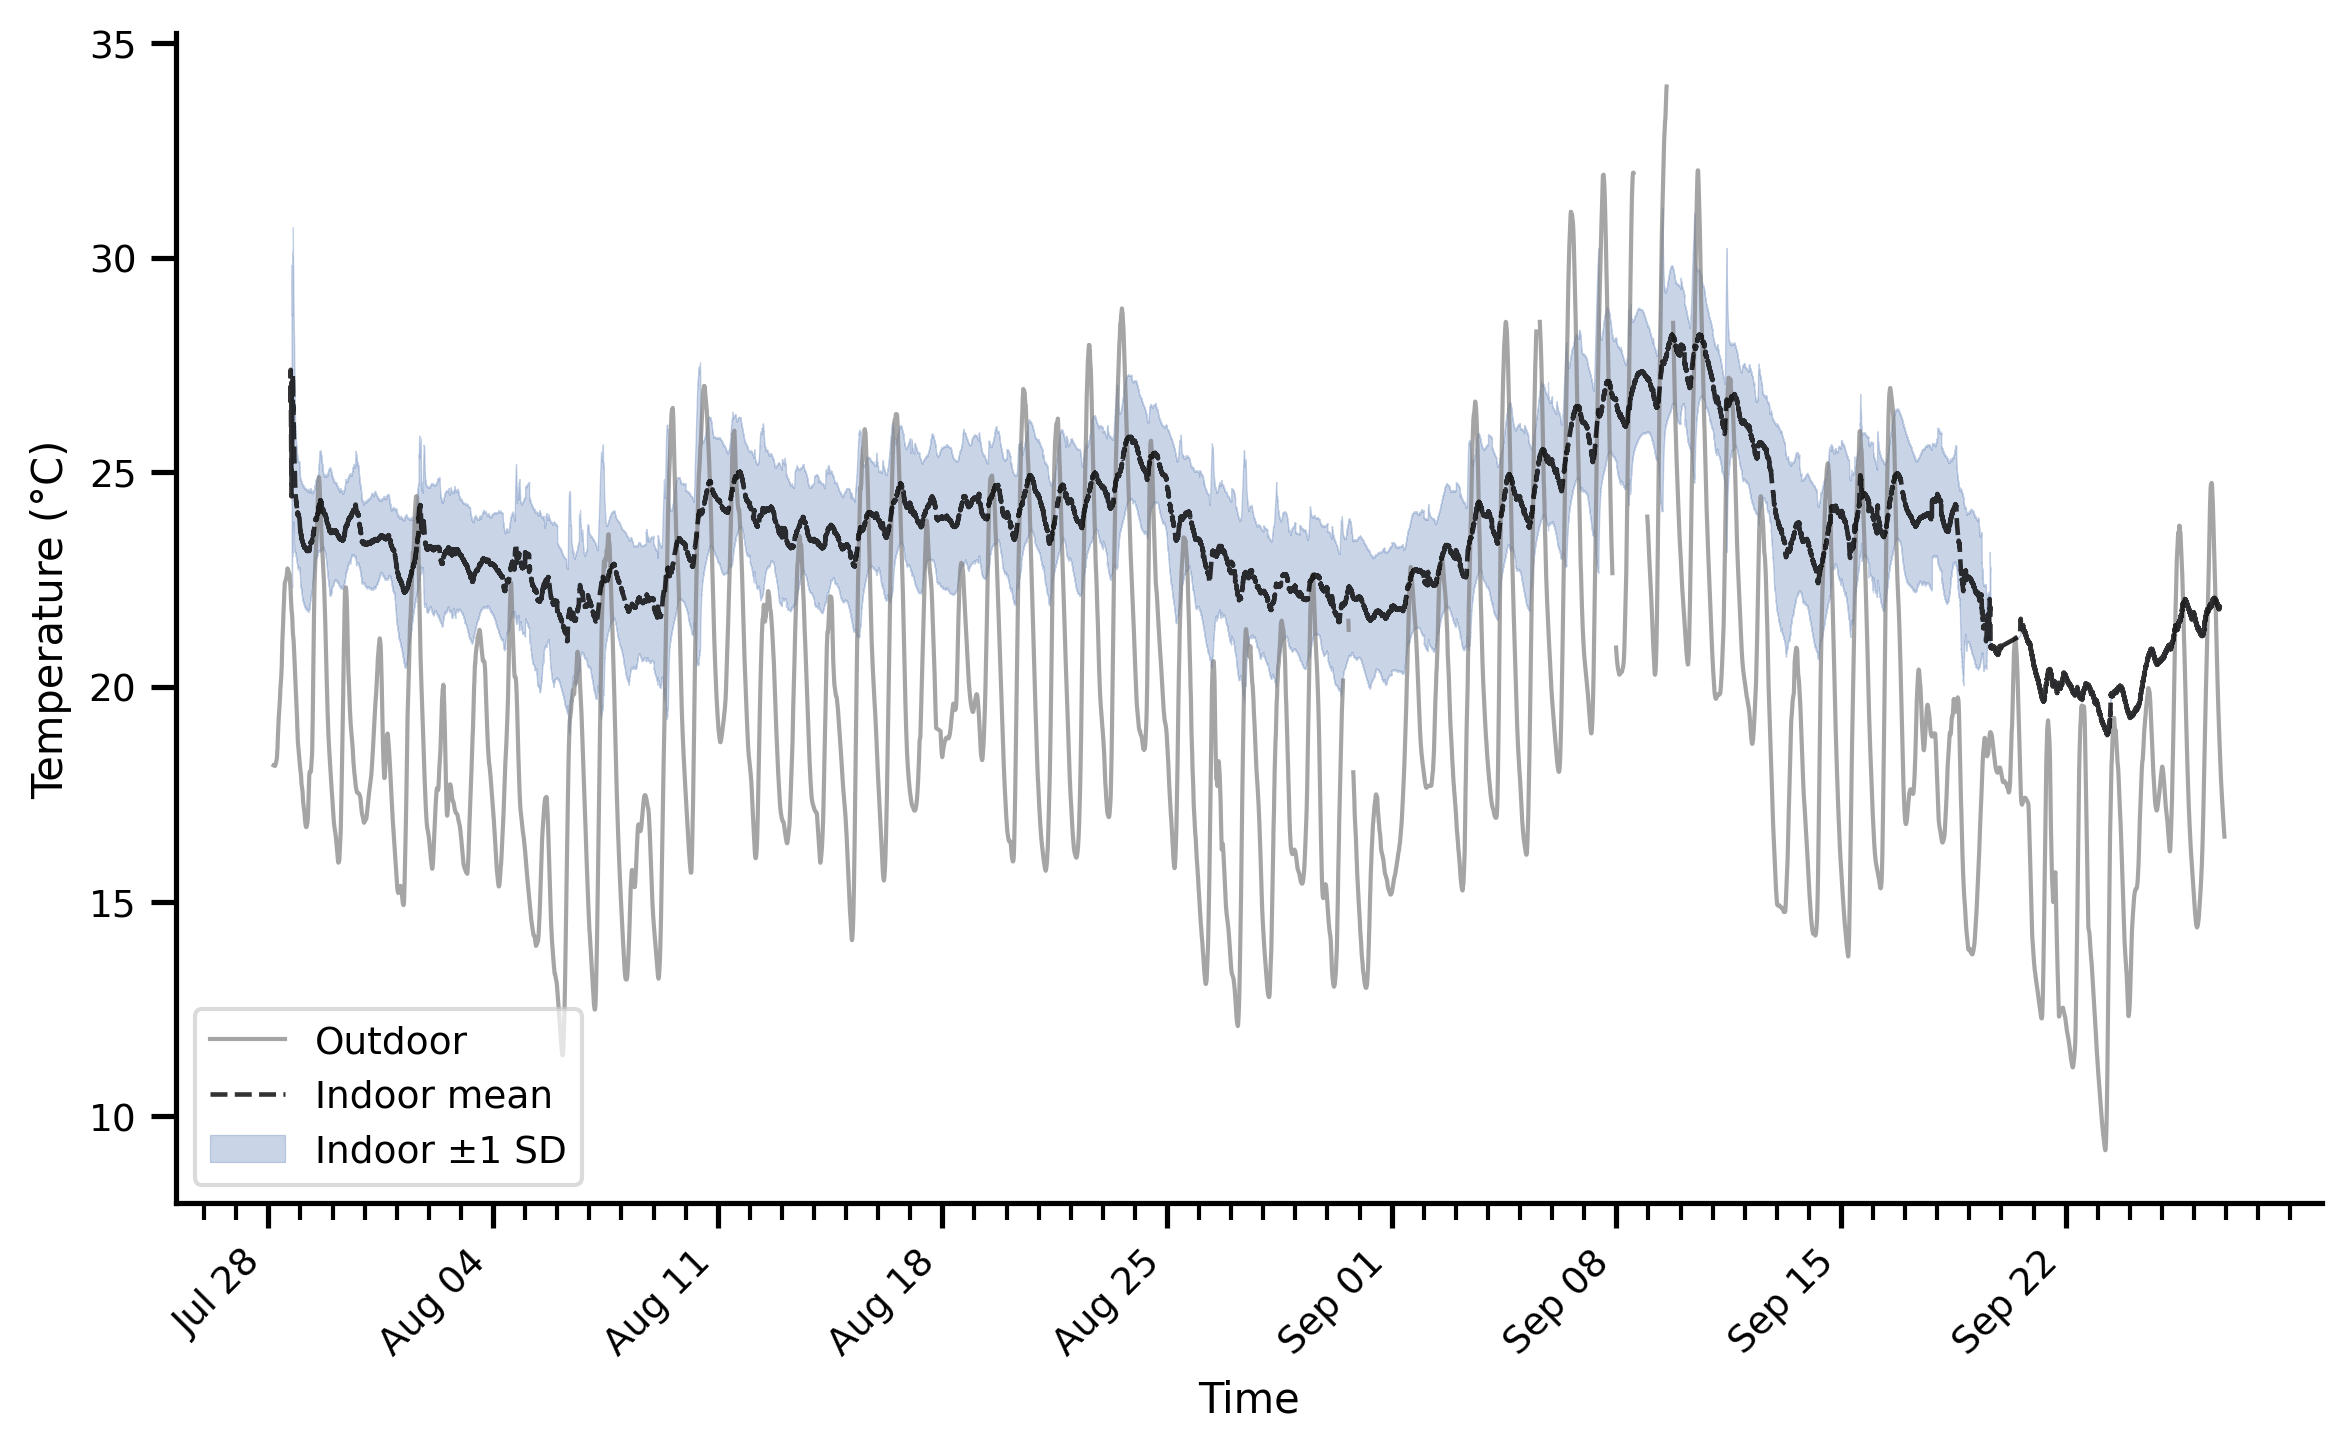

In [47]:
fig, ax1 = plt.subplots(figsize=(8, 5), dpi=300)
sns.set_context("notebook", font_scale=1)
ax1.grid(False)

station_limbo['temp_smooth'] = station_limbo['Air Temperature'].rolling(window=30, center=True).mean()
ax1.plot(station_limbo.index, station_limbo['temp_smooth'], label='Outdoor',
          alpha=0.7, linewidth=1.0, linestyle='-', color='tab:grey')

ax1.plot(temperature_df.index, temperature_df['mean'], c='black', alpha=0.8,
          linewidth=1.1, linestyle='--', label='Indoor mean')

ax1.fill_between(temperature_df.index,
                  temperature_df['mean'] - temperature_df['std'],
                  temperature_df['mean'] + temperature_df['std'],
                  color='#4C72B0', alpha=0.3, edgecolor='#4C72B0',
                  linewidth=0.3, label='Indoor ±1 SD')

end = pd.Timestamp(temperature_df.index.max()).normalize()

major_ticks = pd.date_range(start, end, freq='7D')
minor_ticks = pd.date_range(start, end, freq='1D')

ax1.set_xticks(major_ticks)
ax1.set_xticks(minor_ticks, minor=True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

ax1.xaxis.set_minor_locator(mdates.DayLocator())

ax1.spines[['top', 'right']].set_visible(False)
ax1.set_xlabel('Time', fontsize=10)
ax1.set_ylabel('Temperature (°C)', fontsize=10)
ax1.tick_params(axis='both', labelsize=9)
plt.xticks(rotation=45, ha='right')

lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines, labels, loc='lower left', framealpha=0.7, fontsize=9)

plt.tight_layout()
plt.savefig('temp_comparison.pdf', bbox_inches='tight')
plt.show()

# Temperature and building age illustration

## Household temperature statistics

In [19]:
household_temp={}

for index in sensors_data:
    df = sensors_data[index]

    household_temp[index] = [df['TEMP'].mean(), df['TEMP'].max(), df['TEMP'].min(), df['TEMP'].var(), df['TEMP'].std(), df['TEMP'].max()-df['TEMP'].min()]

temp_all = pd.DataFrame.from_dict(household_temp,orient='index',columns=['mean','max','min', 'var', 'std', 'range'])

In [20]:
temp_all.head()

,mean,max,min,var,std,range
BL007-02,24.416108,30.25,20.52,4.075531,2.018794,9.73
BL007-04,25.562882,29.19,20.54,1.602883,1.266050,8.65
BL007-07,23.537119,30.70,20.00,3.108579,1.763116,10.70
BL007-09,25.729245,30.40,22.02,2.877305,1.696262,8.38
BL007-13,25.067022,28.86,18.98,1.915257,1.383928,9.88


## Join building data

In [21]:
# join sensor statistics (at household level) with building characteristics
temp_join = temp_all.merge(df_building,how='left',left_index=True, right_on='ID')

## Visualisation

In [22]:
temp_join.columns

Index(['mean', 'max', 'min', 'var', 'std', 'range', 'Unnamed: 0', 'ID',
       'Construction Age Band', 'Floor Description', 'Walls Description',
       'Windows Description', 'Roof Description'],
      dtype='object')

In [23]:
temp_join['Construction Age Band'].value_counts()

Construction Age Band
2002 onwards    11
1950-2002       10
1900-1949        7
before 1900      2
Name: count, dtype: int64

In [24]:
temp_join['Floor Description'].value_counts()

Floor Description
Other premises/dwellings below                             19
No or limited insulation                                    6
Insulated: average thermal transmittance 0.10-0.2 W/m2K     5
Name: count, dtype: int64

In [25]:
temp_join['Walls Description'].value_counts()

Walls Description
No insulation                                    14
Average thermal transmittance 0.10-0.20 W/m2K     7
Partial insulation                                4
Average thermal transmittance 0.21-0.30 W/m2K     3
Cavity wall, filled cavity                        2
Name: count, dtype: int64

In [26]:
temp_join['Windows Description'].value_counts()

Windows Description
Double glazed               15
High performance glazing    10
Single glazed                5
Name: count, dtype: int64

In [27]:
temp_join['Roof Description'].value_counts()

Roof Description
Other premises/dwellings above                 13
Average thermal transmittance 0.1-0.2 W/m2K     5
Pitched, 50-75mm loft insulation                4
Flat, no or limited insulation                  3
Pitched, 100-250mm loft insulation              2
Pitched, no insulation                          2
Roof room(s), no insulation                     1
Name: count, dtype: int64

In [28]:
# set the color palette for the boxplots
pal = "magma"

C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\2608101188.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Construction Age Band', y='mean', data=temp_join, palette=pal, order=['before 1900', '1900-1949', '1950-2002', '2002 onwards'], ax=ax1)
C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\2608101188.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels=['Pre 1900', '1900-1949', '1950-2002', 'Post 2002'],rotation=45,ha='right',fontsize=9)
C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\2608101188.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Floor Description',

[Text(0, 0, 'Other dwellings above'),
 Text(1, 0, 'Pitched, no insulation'),
 Text(2, 0, 'Flat, no or limited insulation'),
 Text(3, 0, 'Roof room(s), no insulation'),
 Text(4, 0, 'Pitched, 50-75mm loft insulation'),
 Text(5, 0, 'Pitched, 100-250mm loft insulation'),
 Text(6, 0, 'U-value 0.1-0.2 W/m2K')]

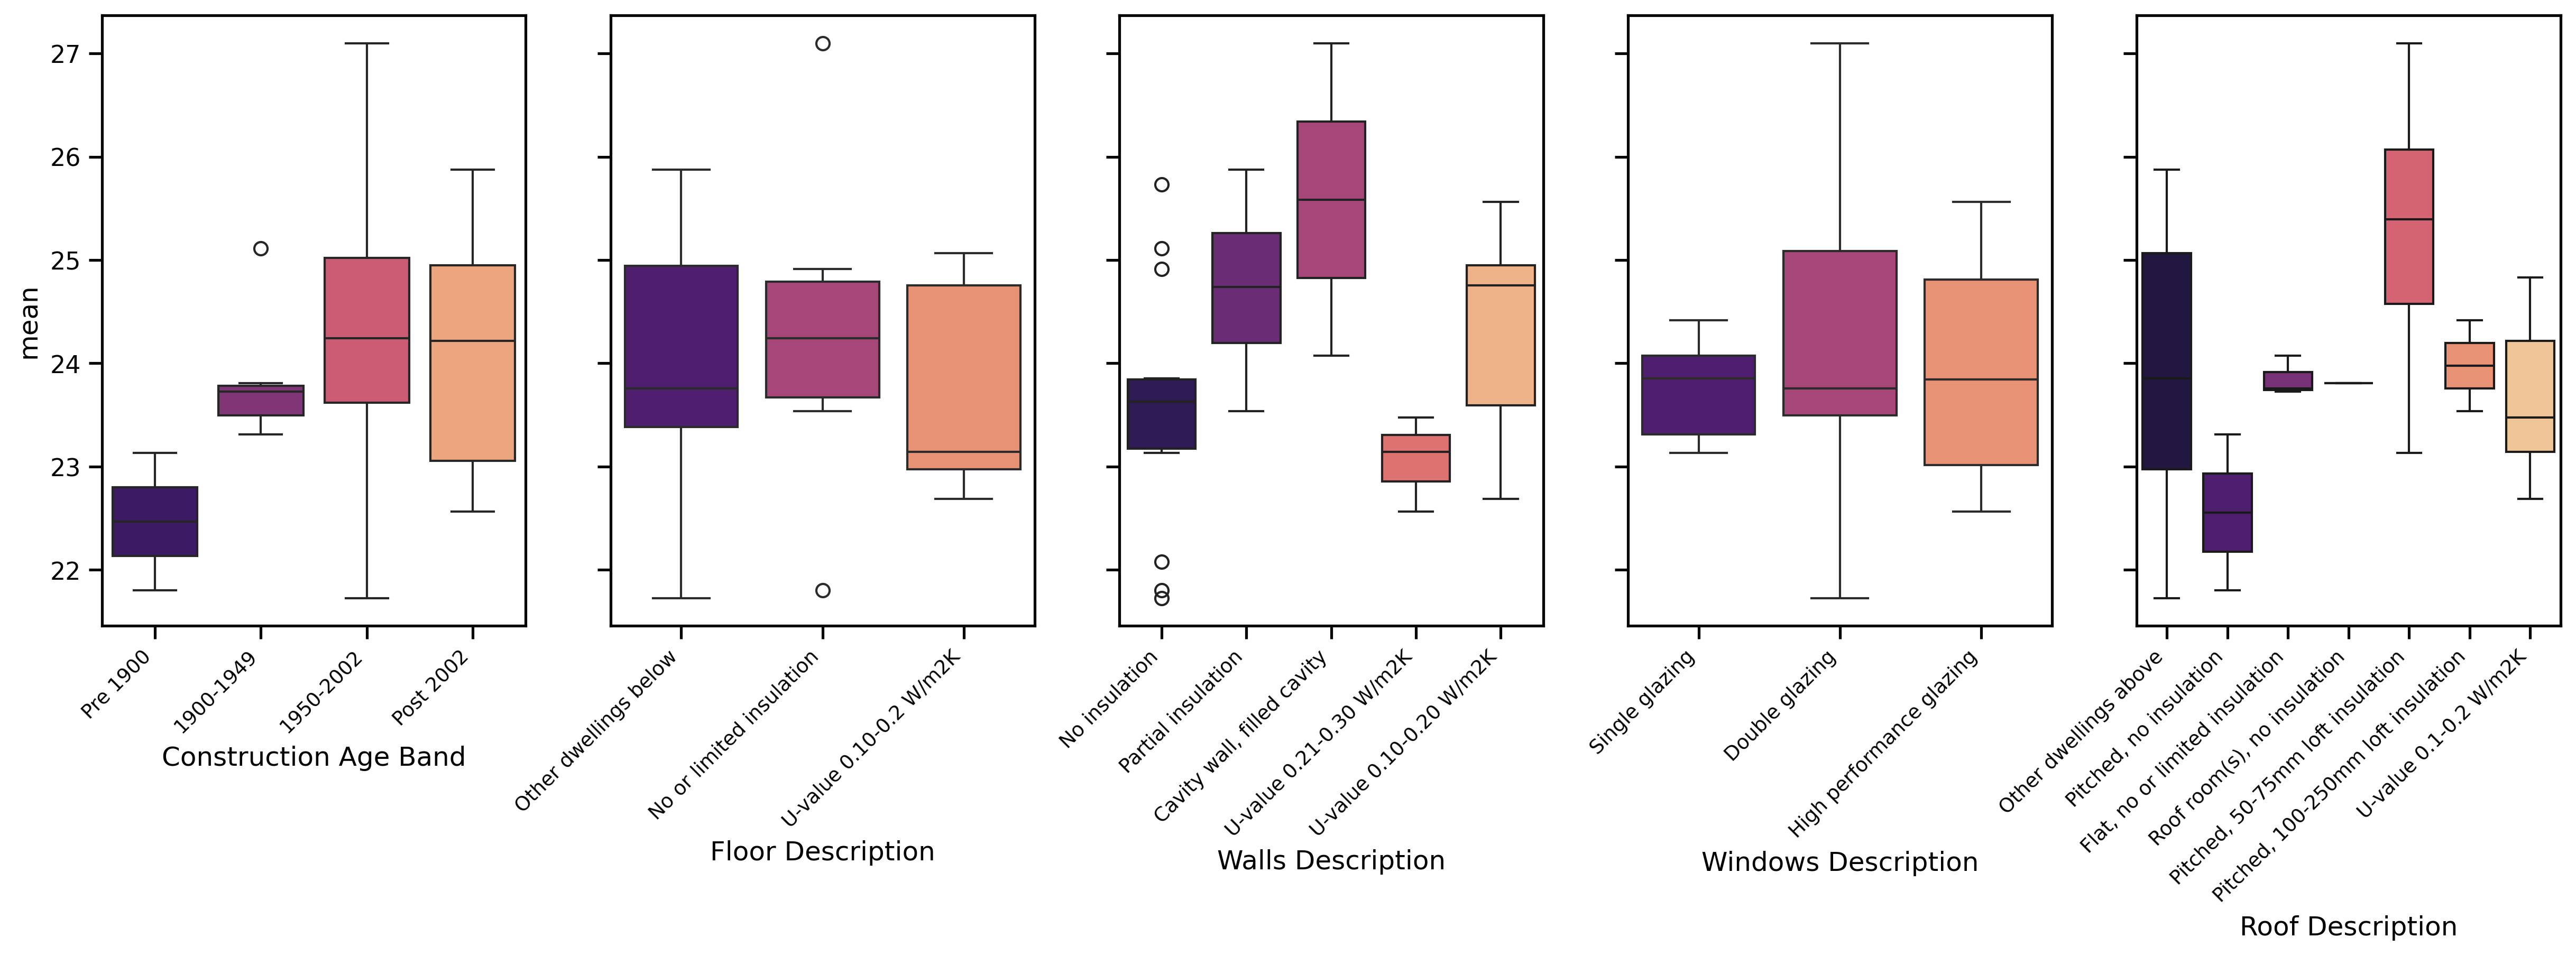

In [29]:
# Plot: temperature mean by building conditions
fig, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5,figsize=(20, 5),dpi=300, sharey=True)

sns.boxplot(x='Construction Age Band', y='mean', data=temp_join, palette=pal, order=['before 1900', '1900-1949', '1950-2002', '2002 onwards'], ax=ax1)
ax1.set_xticklabels(labels=['Pre 1900', '1900-1949', '1950-2002', 'Post 2002'],rotation=45,ha='right',fontsize=9)

sns.boxplot(x='Floor Description', y='mean', data=temp_join, palette=pal, ax=ax2, order=['Other premises/dwellings below','No or limited insulation', 'Insulated: average thermal transmittance 0.10-0.2 W/m2K'])
ax2.set_xticklabels(labels=['Other dwellings below', 'No or limited insulation', 'U-value 0.10-0.2 W/m2K'],rotation=45,ha='right',fontsize=9)

sns.boxplot(x='Walls Description', y='mean', data=temp_join, palette=pal, ax=ax3, order=['No insulation','Partial insulation','Cavity wall, filled cavity','Average thermal transmittance 0.21-0.30 W/m2K','Average thermal transmittance 0.10-0.20 W/m2K'])
ax3.set_xticklabels(labels=['No insulation', 'Partial insulation', 'Cavity wall, filled cavity', 'U-value 0.21-0.30 W/m2K', 'U-value 0.10-0.20 W/m2K'], rotation=45, ha='right', fontsize=9)

sns.boxplot(x='Windows Description', y='mean', data=temp_join, palette=pal, ax=ax4, order=['Single glazed','Double glazed','High performance glazing'])
ax4.set_xticklabels(labels=['Single glazing', 'Double glazing', 'High performance glazing'], rotation=45, ha='right', fontsize=9)

sns.boxplot(x='Roof Description', y='mean', data=temp_join, palette=pal, ax=ax5, order=['Other premises/dwellings above','Pitched, no insulation','Flat, no or limited insulation',
                                                                                           'Roof room(s), no insulation','Pitched, 50-75mm loft insulation','Pitched, 100-250mm loft insulation',
                                                                                           'Average thermal transmittance 0.1-0.2 W/m2K'])
ax5.set_xticklabels(labels=['Other dwellings above', 'Pitched, no insulation', 'Flat, no or limited insulation',
                            'Roof room(s), no insulation', 'Pitched, 50-75mm loft insulation', 'Pitched, 100-250mm loft insulation',
                            'U-value 0.1-0.2 W/m2K'], rotation=45, ha='right', fontsize=9)

C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\695994397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Construction Age Band', y='std', data=temp_join, palette=pal, order=['before 1900', '1900-1949', '1950-2002', '2002 onwards'], ax=ax1)
C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\695994397.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels=['Pre 1900', '1900-1949', '1950-2002', 'Post 2002'],rotation=45,ha='right',fontsize=9)
C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\695994397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Floor Description', y='

[Text(0, 0, 'Other dwellings above'),
 Text(1, 0, 'Pitched, no insulation'),
 Text(2, 0, 'Flat, no or limited insulation'),
 Text(3, 0, 'Roof room(s), no insulation'),
 Text(4, 0, 'Pitched, 50-75mm loft insulation'),
 Text(5, 0, 'Pitched, 100-250mm loft insulation'),
 Text(6, 0, 'U-value 0.1-0.2 W/m2K')]

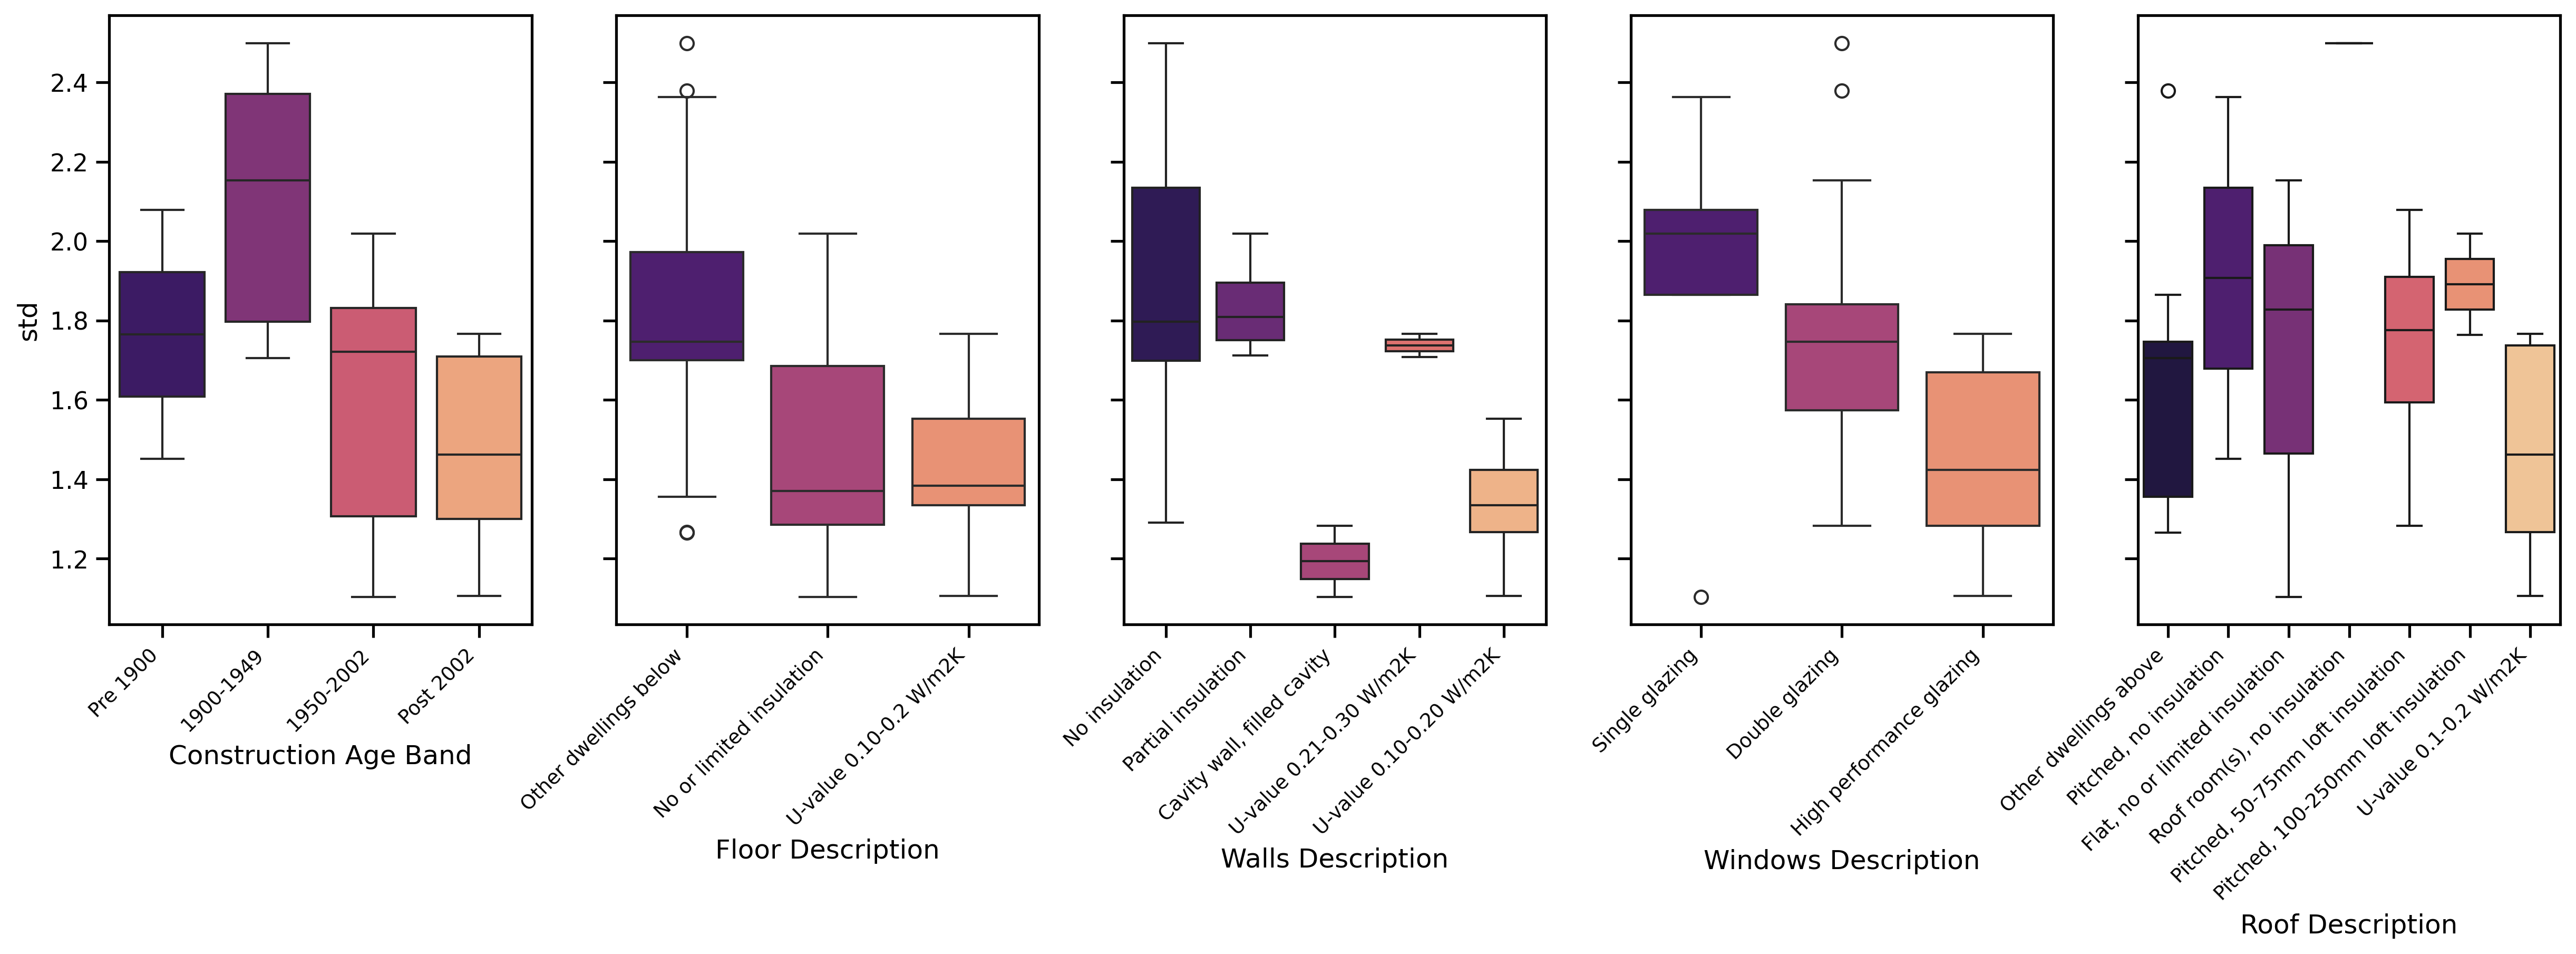

In [30]:
# Plot: temperature std mean by building conditions
fig, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5,figsize=(20, 5),dpi=300, sharey=True)

sns.boxplot(x='Construction Age Band', y='std', data=temp_join, palette=pal, order=['before 1900', '1900-1949', '1950-2002', '2002 onwards'], ax=ax1)
ax1.set_xticklabels(labels=['Pre 1900', '1900-1949', '1950-2002', 'Post 2002'],rotation=45,ha='right',fontsize=9)

sns.boxplot(x='Floor Description', y='std', data=temp_join, palette=pal, ax=ax2, order=['Other premises/dwellings below','No or limited insulation', 'Insulated: average thermal transmittance 0.10-0.2 W/m2K'])
ax2.set_xticklabels(labels=['Other dwellings below', 'No or limited insulation', 'U-value 0.10-0.2 W/m2K'],rotation=45,ha='right',fontsize=9)

sns.boxplot(x='Walls Description', y='std', data=temp_join, palette=pal, ax=ax3, order=['No insulation','Partial insulation','Cavity wall, filled cavity','Average thermal transmittance 0.21-0.30 W/m2K','Average thermal transmittance 0.10-0.20 W/m2K'])
ax3.set_xticklabels(labels=['No insulation', 'Partial insulation', 'Cavity wall, filled cavity', 'U-value 0.21-0.30 W/m2K', 'U-value 0.10-0.20 W/m2K'], rotation=45, ha='right', fontsize=9)

sns.boxplot(x='Windows Description', y='std', data=temp_join, palette=pal, ax=ax4, order=['Single glazed','Double glazed','High performance glazing'])
ax4.set_xticklabels(labels=['Single glazing', 'Double glazing', 'High performance glazing'], rotation=45, ha='right', fontsize=9)

sns.boxplot(x='Roof Description', y='std', data=temp_join, palette=pal, ax=ax5, order=['Other premises/dwellings above','Pitched, no insulation','Flat, no or limited insulation',
                                                                                           'Roof room(s), no insulation','Pitched, 50-75mm loft insulation','Pitched, 100-250mm loft insulation',
                                                                                           'Average thermal transmittance 0.1-0.2 W/m2K'])
ax5.set_xticklabels(labels=['Other dwellings above', 'Pitched, no insulation', 'Flat, no or limited insulation',
                            'Roof room(s), no insulation', 'Pitched, 50-75mm loft insulation', 'Pitched, 100-250mm loft insulation',
                            'U-value 0.1-0.2 W/m2K'], rotation=45, ha='right', fontsize=9)

C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\1137213257.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=45, ha='right')
C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\1137213257.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=45, ha='right')
C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\1137213257.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=45, ha='right')
C:\Users\jobbo\AppData\Local\Temp\ipykernel_33248\1137213257.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotat

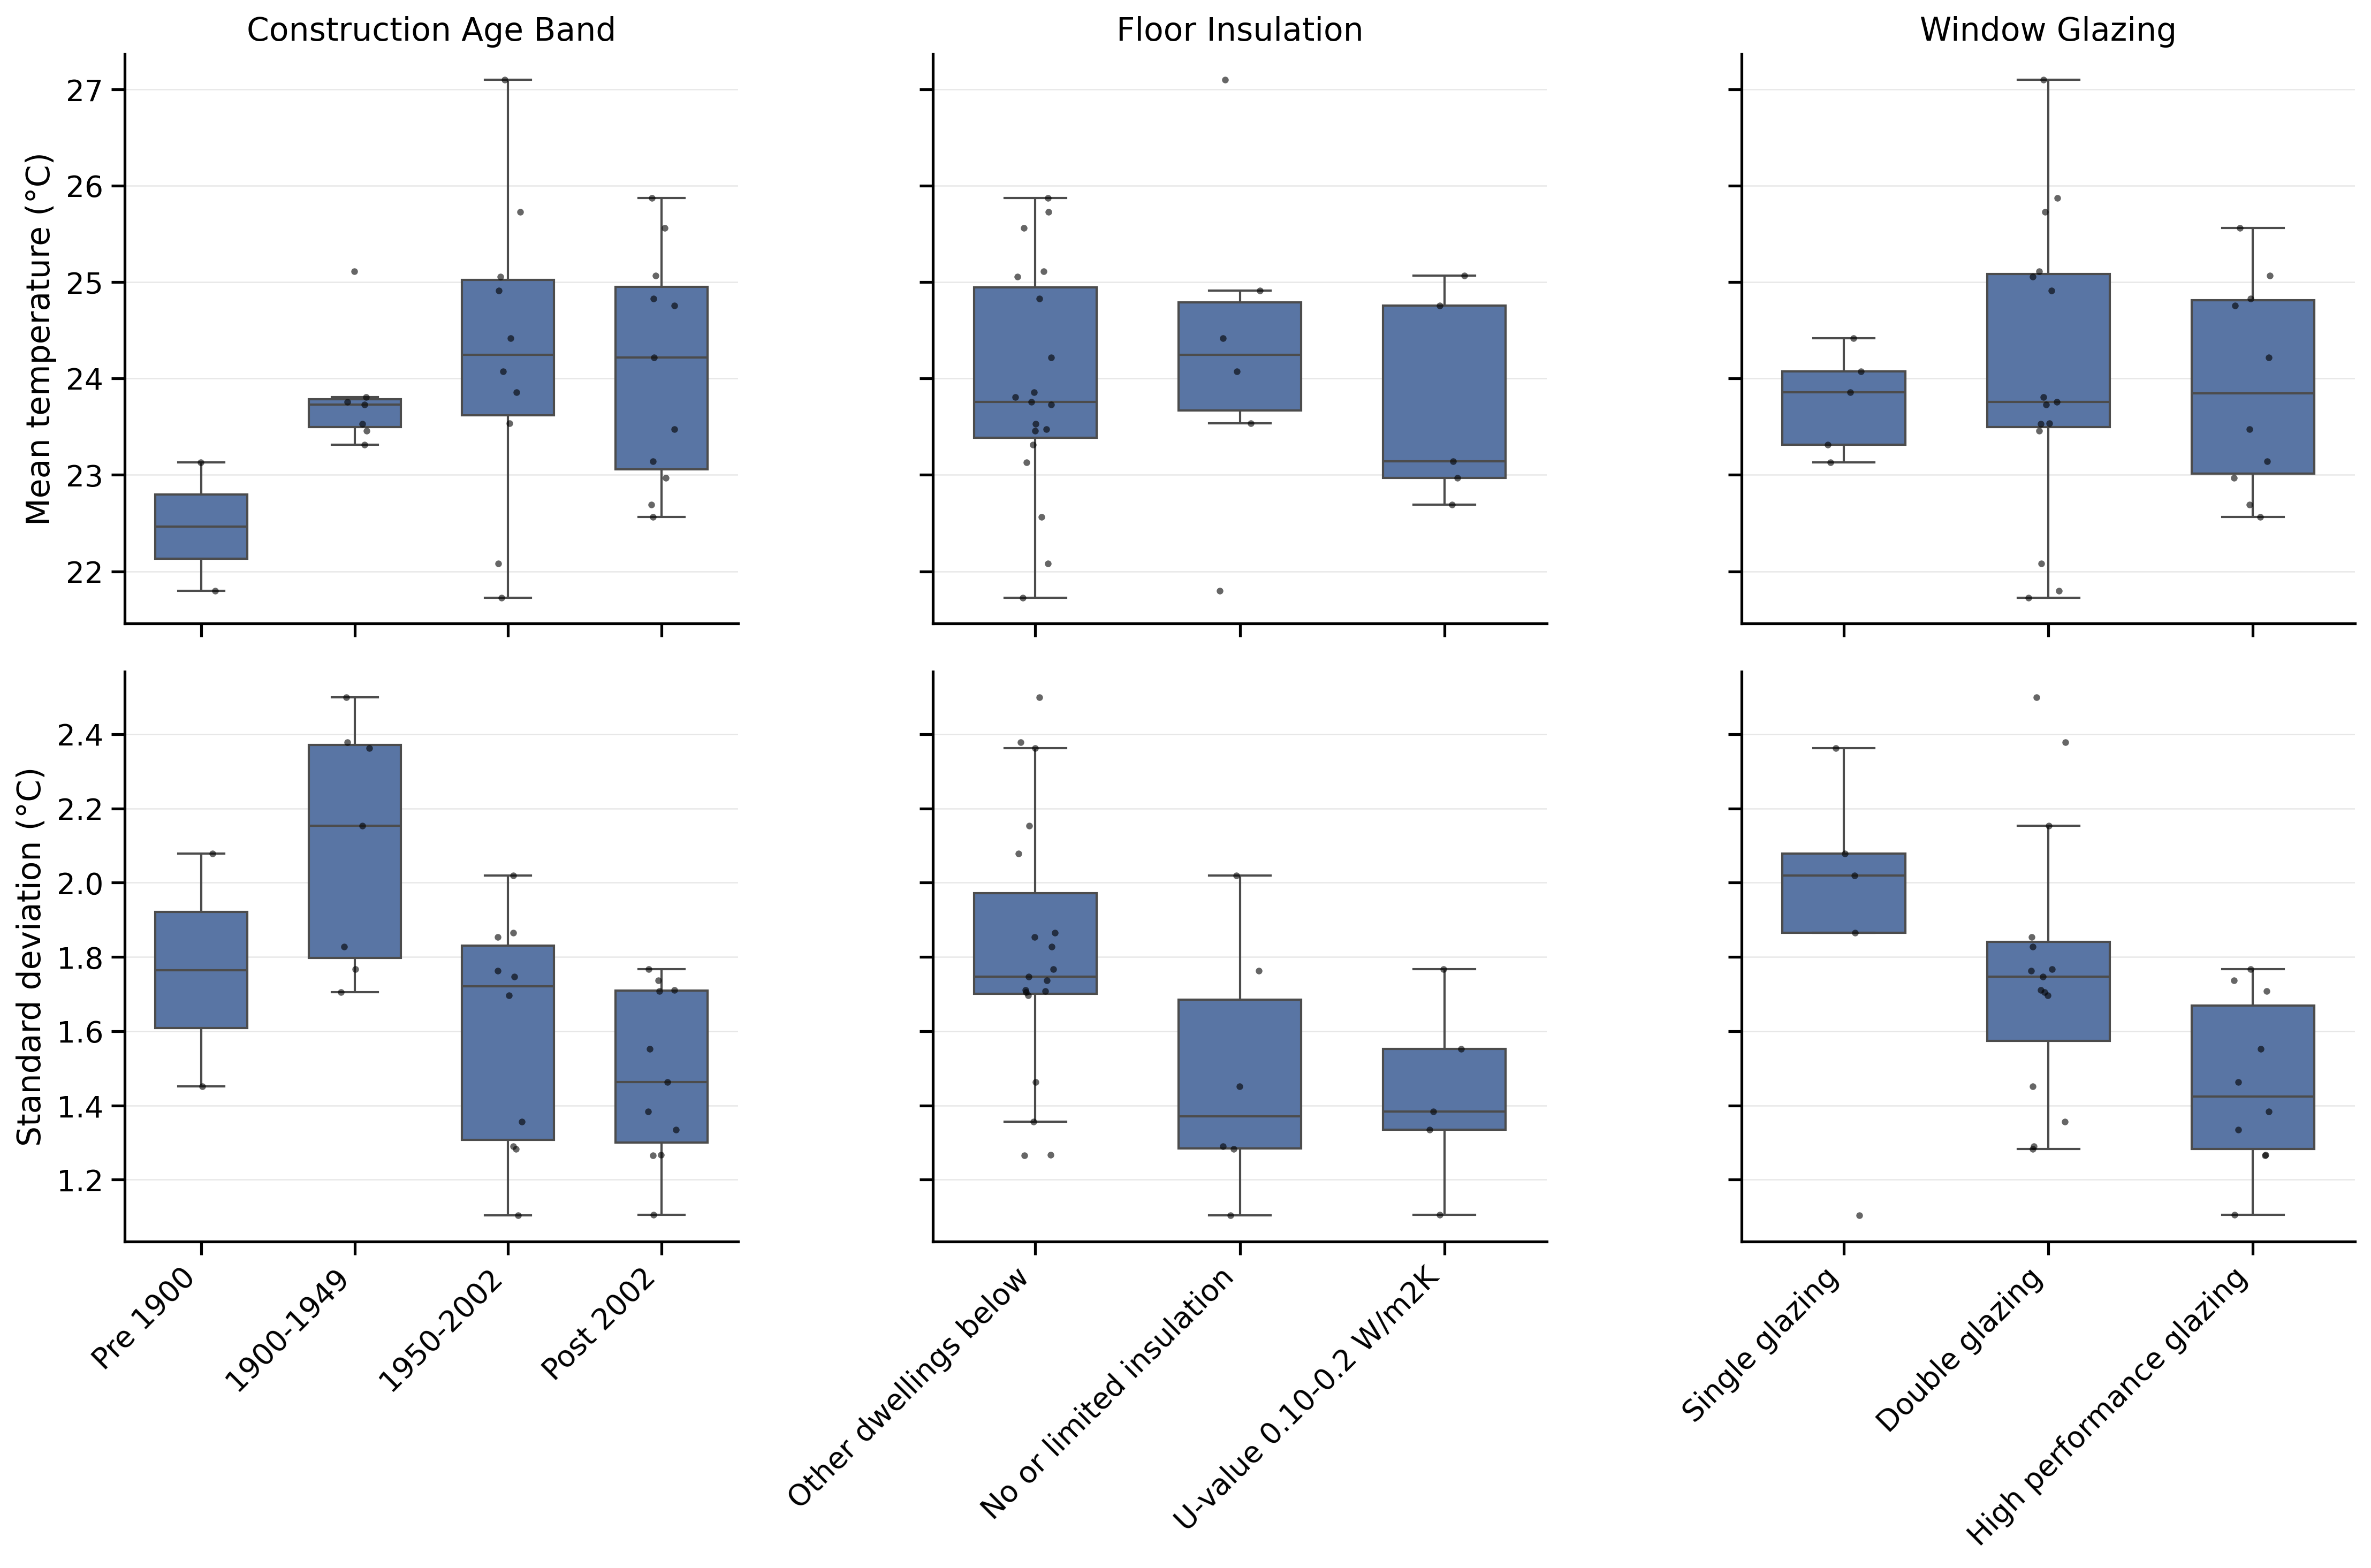

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=300, sharey='row', sharex='col')
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()
sns.set_context("notebook", font_scale=1.2)

box_color = '#4C72B0'
point_kwargs = dict(color='black', size=3, alpha=0.6, jitter=True)

def plot_panel(ax, x, y, order, xticklabels, title=None, ylabel=None):
    sns.boxplot(x=x, y=y, data=temp_join, order=order, ax=ax,
                color=box_color, showfliers=False, width=0.6)
    sns.stripplot(x=x, y=y, data=temp_join, order=order, ax=ax, **point_kwargs)
    ax.set_xticklabels(xticklabels, rotation=45, ha='right')
    ax.set_xlabel('')
    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel('')
    ax.grid(axis='y', color='#DDDDDD', linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    # sample size annotation
    counts = temp_join.groupby(x)[y].count()
    ymax = ax.get_ylim()[1]

age_order = ['before 1900', '1900-1949', '1950-2002', '2002 onwards']
age_labels = ['Pre 1900', '1900-1949', '1950-2002', 'Post 2002']
floor_order = ['Other premises/dwellings below', 'No or limited insulation',
               'Insulated: average thermal transmittance 0.10-0.2 W/m2K']
floor_labels = ['Other dwellings below', 'No or limited insulation', 'U-value 0.10-0.2 W/m2K']
win_order = ['Single glazed', 'Double glazed', 'High performance glazing']
win_labels = ['Single glazing', 'Double glazing', 'High performance glazing']

plot_panel(ax1, 'Construction Age Band', 'mean', age_order, age_labels,
           title='Construction Age Band', ylabel='Mean temperature (°C)')
plot_panel(ax2, 'Floor Description', 'mean', floor_order, floor_labels,
           title='Floor Insulation')
plot_panel(ax3, 'Windows Description', 'mean', win_order, win_labels,
           title='Window Glazing')
plot_panel(ax4, 'Construction Age Band', 'std', age_order, age_labels,
           ylabel='Standard deviation (°C)')
plot_panel(ax5, 'Floor Description', 'std', floor_order, floor_labels)
plot_panel(ax6, 'Windows Description', 'std', win_order, win_labels)

plt.tight_layout()
plt.savefig('temp_by_building_features.pdf', bbox_inches='tight')
plt.show()